### MIG Cement Demand Forecasting
### 03: Exploratory Data Analysis

### Purpose

The purpose of this notebook is to understand the operational patterns contained in the cleaned MIG cement dataset before feature engineering and forecasting.

The analysis will focus on business questions relevant to cement demand and inventory management.

The EDA will investigate:

1. overall cement demand,
2. differences in demand across construction sites,
3. differences across cement types,
4. temporal patterns and seasonality,
5. demand volatility,
6. planned versus actual cement consumption,
7. relationships between weather and demand,
8. inventory behaviour,
9. silo utilization and capacity violations, and
10. differences associated with site region and behavior.

The objective is not simply to generate visualizations. Each analysis will address a specific operational question that may influence the design of the forecasting and inventory-management system.

#### Load Cleaned dataset

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
data =pd.read_csv(r"C:\Users\hp\Desktop\Amdari Internship\Projects\Cement Forecasting\data\cleaned_dataset.csv")
data.head()

,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity,region,behavior,opening_capacity_violation,closing_capacity_violation
0,2022-01-01,SITE_001,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448,North,aggressive,False,False
1,2022-01-02,SITE_001,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448,North,aggressive,False,False
2,2022-01-03,SITE_001,CEM_III,38.69,38.69,38.56,47.19,47.06,2.64,6.40,448,North,aggressive,False,False
3,2022-01-04,SITE_001,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448,North,aggressive,False,False
4,2022-01-05,SITE_001,CEM_III,56.88,47.04,32.64,14.40,0.00,2.69,8.97,448,North,aggressive,False,False


In [3]:
# Check to run a few check to ensure the data was truly cleaned
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32880 entries, 0 to 32879
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   date                        32880 non-null  str    
 1   site_id                     32880 non-null  str    
 2   cement_type                 32880 non-null  str    
 3   planned_pour_tonnes         32880 non-null  float64
 4   consumed_tonnes             32880 non-null  float64
 5   opening_inventory_tonnes    32880 non-null  float64
 6   deliveries_tonnes           32880 non-null  float64
 7   closing_inventory_tonnes    32880 non-null  float64
 8   rain_mm                     32880 non-null  float64
 9   avg_temp_c                  32880 non-null  float64
 10  silo_capacity               32880 non-null  int64  
 11  region                      32880 non-null  str    
 12  behavior                    32880 non-null  str    
 13  opening_capacity_violation  32880 non-null

In [4]:
#Data time as string rather than dateime
data['date'] =pd.to_datetime(data['date'])

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32880 entries, 0 to 32879
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        32880 non-null  datetime64[us]
 1   site_id                     32880 non-null  str           
 2   cement_type                 32880 non-null  str           
 3   planned_pour_tonnes         32880 non-null  float64       
 4   consumed_tonnes             32880 non-null  float64       
 5   opening_inventory_tonnes    32880 non-null  float64       
 6   deliveries_tonnes           32880 non-null  float64       
 7   closing_inventory_tonnes    32880 non-null  float64       
 8   rain_mm                     32880 non-null  float64       
 9   avg_temp_c                  32880 non-null  float64       
 10  silo_capacity               32880 non-null  int64         
 11  region                      32880 non-null  str           
 12  b

In [6]:
#checking for missing values
data.isnull().sum()

date                          0
site_id                       0
cement_type                   0
planned_pour_tonnes           0
consumed_tonnes               0
opening_inventory_tonnes      0
deliveries_tonnes             0
closing_inventory_tonnes      0
rain_mm                       0
avg_temp_c                    0
silo_capacity                 0
region                        0
behavior                      0
opening_capacity_violation    0
closing_capacity_violation    0
dtype: int64

In [7]:
#checing for duplicates
data.duplicated().sum()

np.int64(0)

In [8]:
# Quick look at the description of the data
data.describe().T

,count,mean,min,25%,50%,75%,max,std
date,32880,2023-07-02 12:00:00,2022-01-01 00:00:00,2022-10-01 18:00:00,2023-07-02 12:00:00,2024-04-01 06:00:00,2024-12-31 00:00:00,NaN
planned_pour_tonnes,32880.0,30.697158,0.0,12.83,33.455,47.6125,69.98,19.493713
consumed_tonnes,32880.0,23.720475,0.0,10.71,19.72,36.4925,69.97,16.846251
opening_inventory_tonnes,32880.0,3066.682205,0.0,1.28,50.71,3298.5225,20646.18,5586.029168
deliveries_tonnes,32880.0,29.293009,0.0,19.3,29.49,39.75,50.0,12.3256
closing_inventory_tonnes,32880.0,3072.254739,0.0,1.27,50.66,3312.0625,20658.87,5593.01591
rain_mm,32880.0,5.00812,0.0,1.44,3.47,6.97,50.0,4.997142
avg_temp_c,32880.0,10.085887,-5.0,3.34,9.99,16.7,35.0,8.519946
silo_capacity,32880.0,317.533333,120.0,230.0,314.0,437.0,487.0,112.813279


In [9]:
data.describe(include ='object').T

,count,unique,top,freq
site_id,32880,30,SITE_001,1096
cement_type,32880,3,CEM_II,11097
region,32880,4,East,13152
behavior,32880,3,aggressive,15344


In [10]:
#A Look look at categorical data
data['site_id'].value_counts().head()

site_id
SITE_001    1096
SITE_002    1096
SITE_003    1096
SITE_004    1096
SITE_005    1096
Name: count, dtype: int64

- We have 30 active site

In [11]:
data['cement_type'].value_counts().head()

cement_type
CEM_II     11097
CEM_I      10913
CEM_III    10870
Name: count, dtype: int64

- 3 type of cement

In [12]:
data['region'].value_counts()

region
East     13152
South    12056
West      4384
North     3288
Name: count, dtype: int64

-  4 regions with East topping the list

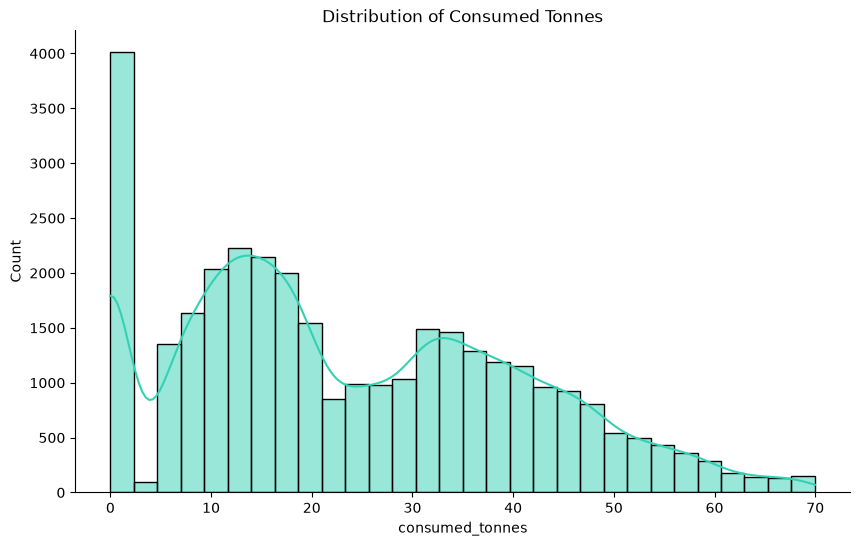

In [13]:
# A Quick look at the statistical distribution of the data
plt.figure(figsize = (10, 6))
sns.histplot(data['consumed_tonnes'], kde = True, color = "#33D1B4", bins = 30)
plt.title("Distribution of Consumed Tonnes")
sns.despine();

In [14]:
data['consumed_tonnes'].describe()

count    32880.000000
mean        23.720475
std         16.846251
min          0.000000
25%         10.710000
50%         19.720000
75%         36.492500
max         69.970000
Name: consumed_tonnes, dtype: float64

- This is shows that consumed_tonnes is righ skewed with some days having nothing consumed, some having over 69 tonnes consumed. with an average consumed_tonnes hitting 23.7 tonnes

In [15]:
#Just a quick overview of the data
eda_overview = pd.Series({
    "Rows": data.shape[0],
    "Columns": data.shape[1],
    "Start date": data["date"].min(),
    "End date": data["date"].max(),
    "Number of sites": data["site_id"].nunique(),
    "Number of cement types": data["cement_type"].nunique(),
    "Total cement consumed (tonnes)": data["consumed_tonnes"].sum(),
    "Average consumption per record (tonnes)": data["consumed_tonnes"].mean()
})

eda_overview

Rows                                                     32880
Columns                                                     15
Start date                                 2022-01-01 00:00:00
End date                                   2024-12-31 00:00:00
Number of sites                                             30
Number of cement types                                       3
Total cement consumed (tonnes)                       779929.21
Average consumption per record (tonnes)              23.720475
dtype: object

#### Distribution of Daily Consumed tonnes

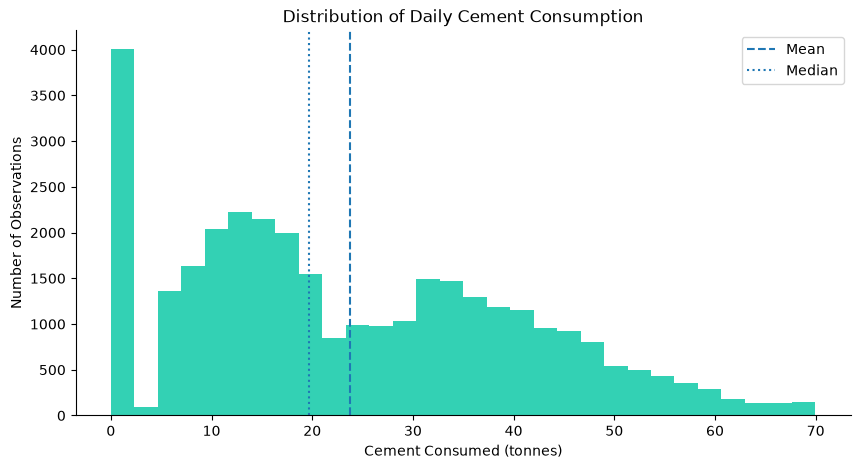

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(
    data["consumed_tonnes"],
    bins=30,
    color ="#33D1B4"
)

plt.axvline(
    data["consumed_tonnes"].mean(),
    linestyle="--",
    label="Mean"
)

plt.axvline(
    data["consumed_tonnes"].median(),
    linestyle=":",
    label="Median"
)


plt.xlabel("Cement Consumed (tonnes)")
plt.ylabel("Number of Observations")
plt.title("Distribution of Daily Cement Consumption")
plt.legend()
sns.despine()

plt.show()

-The mean daily cement consumed is around 23.7 and median consumption hovers around 19 -20 tonnes

#### Daily Consumed tonnes by Site

In [17]:
# Site Consumption Analysis
site_demand = (
    data.groupby("site_id")["consumed_tonnes"]
        .agg(
            total_consumption="sum",
            average_consumption="mean"
        )
        .sort_values("total_consumption", ascending=False)
)

site_demand.round(2).head(10)

,total_consumption,average_consumption
site_id,,
SITE_025,33604.06,30.66
SITE_010,33579.76,30.64
SITE_018,33348.09,30.43
SITE_001,33056.40,30.16
SITE_021,33009.68,30.12
SITE_005,32935.68,30.05
SITE_022,32934.03,30.05
SITE_008,32689.50,29.83
SITE_007,32607.65,29.75


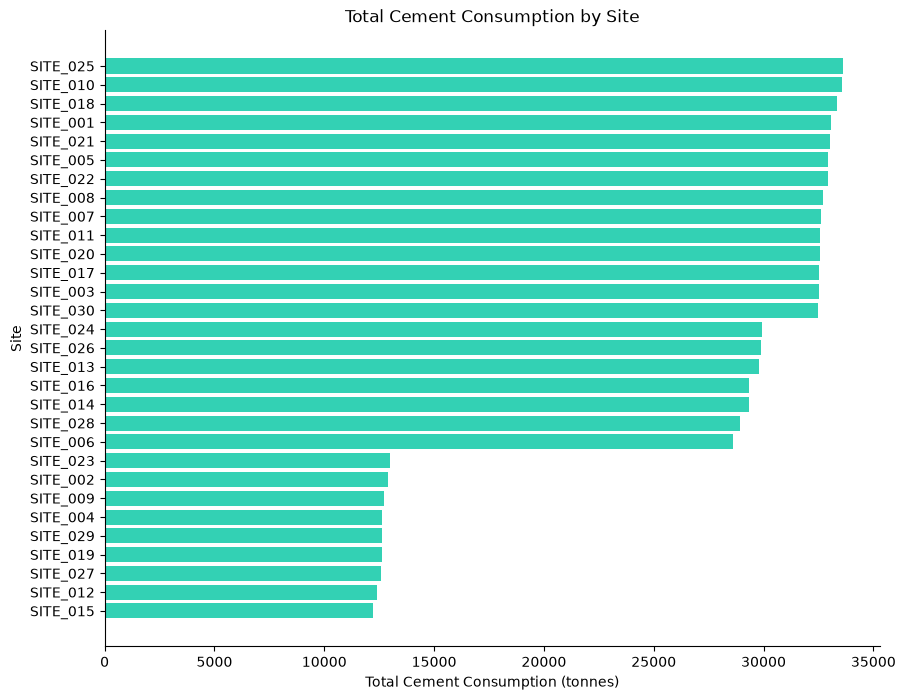

In [18]:
site_demand_sorted = site_demand.sort_values(
    "total_consumption"
)

plt.figure(figsize=(10, 8))

plt.barh(
    site_demand_sorted.index,
    site_demand_sorted["total_consumption"],
    color ="#33D1B4"
)

plt.xlabel("Total Cement Consumption (tonnes)")
plt.ylabel("Site")
plt.title("Total Cement Consumption by Site")

sns.despine()
plt.show()

- The insight is telling, some site clearly show they dominate in daily consumption of tonnes which could be as a result of alot of factors

#### Cement Demand by Daily Consumption tonnes

In [19]:
cement_demand = (
    data.groupby("cement_type")["consumed_tonnes"]
        .agg(
            total_consumption="sum",
            average_consumption="mean",
            median_consumption="median"
        )
        .sort_values("total_consumption", ascending=False)
)

cement_demand.round(2)

,total_consumption,average_consumption,median_consumption
cement_type,,,
CEM_II,263418.26,23.74,19.65
CEM_I,259954.71,23.82,19.79
CEM_III,256556.24,23.60,19.74


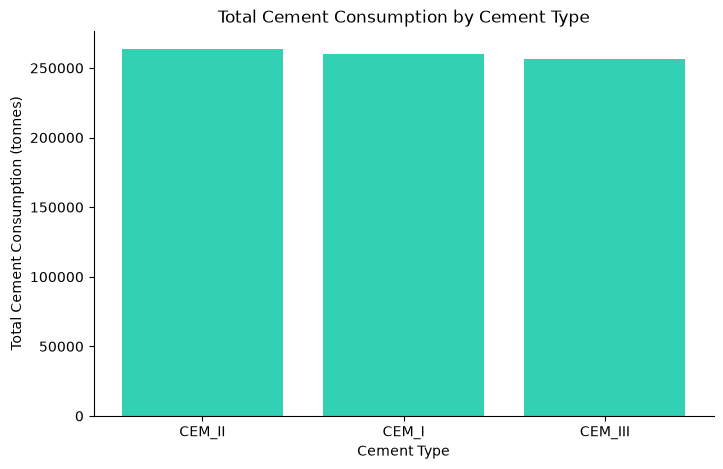

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    cement_demand.index,
    cement_demand["total_consumption"],
    color ="#33D1B4"
)

plt.xlabel("Cement Type")
plt.ylabel("Total Cement Consumption (tonnes)")
plt.title("Total Cement Consumption by Cement Type")

sns.despine()
plt.show()

- These does not tell much about cement consumption by type. They all fairly consumed similarly amount. Let's look at the % share of the total consumption. This could tell much rather just looking at the absolute values

In [21]:
cement_demand["demand_share_pct"] = (
    cement_demand["total_consumption"]
    / cement_demand["total_consumption"].sum()
    * 100
)

cement_demand.round(2).iloc[:, 3]

cement_type
CEM_II     33.77
CEM_I      33.33
CEM_III    32.89
Name: demand_share_pct, dtype: float64

- Over 34% of total cement consumption was attributed to CEM II. The consumption patterns look similarly across tyep.

#### Demand over time and season

 Getting to know the cement demand across different time sphere would help us identify trends and patterns that would be useful when forecasting.

In [22]:
# Just looking at daily demand
daily_demand = (
    data.groupby("date")["consumed_tonnes"]
        .sum()
        .sort_index()
)

daily_demand.head()

date
2022-01-01    936.43
2022-01-02    887.12
2022-01-03    823.76
2022-01-04    713.23
2022-01-05    990.98
Name: consumed_tonnes, dtype: float64

In [23]:
# Looking at the monthly demand trend
monthly_demand_trend = daily_demand.resample("ME").mean()

monthly_demand_trend.head()

date
2022-01-31    744.559355
2022-02-28    705.047857
2022-03-31    727.820968
2022-04-30    724.105333
2022-05-31    692.747742
Freq: ME, Name: consumed_tonnes, dtype: float64

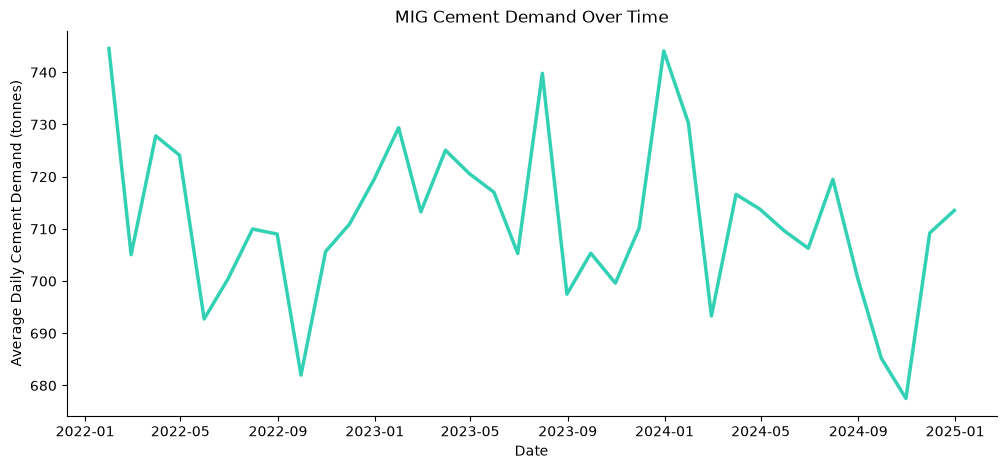

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_demand_trend.index,
    monthly_demand_trend.values,
    linewidth =2.5,
    color ="#33D1B4"
)

plt.xlabel("Date")
plt.ylabel("Average Daily Cement Demand (tonnes)")
plt.title("MIG Cement Demand Over Time")

sns.despine()
plt.show()

- There is clear fluctuation in daily cememt consumption over time. We look at this more later. let now look at the monthly trend

In [25]:
daily_demand_df = daily_demand.reset_index()

daily_demand_df["month"] = daily_demand_df["date"].dt.month

In [26]:
monthly_seasonality = (
    daily_demand_df.groupby("month")["consumed_tonnes"]
        .mean()
)

monthly_seasonality

month
1     734.744301
2     703.748706
3     723.166989
4     719.490778
5     706.453978
6     703.990556
7     723.092581
8     702.399247
9     690.855444
10    694.262151
11    710.092667
12    725.686344
Name: consumed_tonnes, dtype: float64

In [27]:
monthly_seasonality = (
    daily_demand_df.groupby("month")["consumed_tonnes"]
        .mean()
)

monthly_seasonality

month
1     734.744301
2     703.748706
3     723.166989
4     719.490778
5     706.453978
6     703.990556
7     723.092581
8     702.399247
9     690.855444
10    694.262151
11    710.092667
12    725.686344
Name: consumed_tonnes, dtype: float64

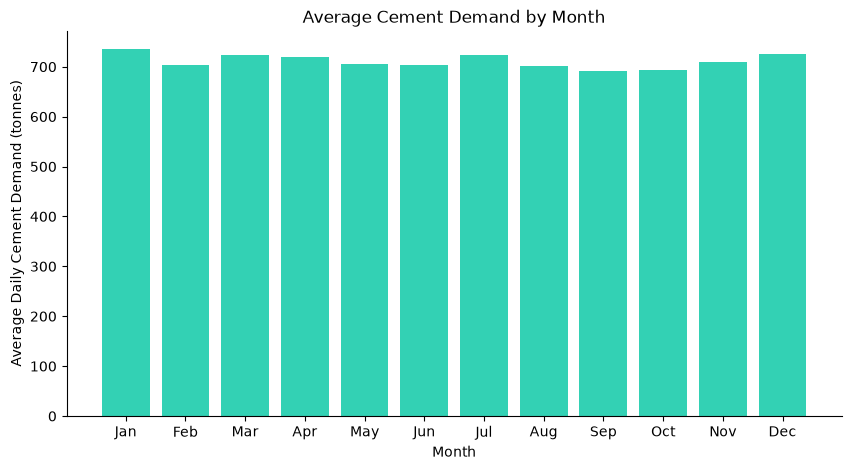

In [28]:
month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(10, 5))

plt.bar(
    monthly_seasonality.index,
    monthly_seasonality.values,
    color ="#33D1B4"
)

plt.xlabel("Month")
plt.ylabel("Average Daily Cement Demand (tonnes)")
plt.title("Average Cement Demand by Month")

plt.xticks(
    ticks=range(1, 13),
    labels=month_names
)

sns.despine()
plt.show()

- Monthly cement consumption does not vary that much across months. Maybe weekly demand could tell more story 

In [29]:
daily_demand_df["day_of_week"] = (
    daily_demand_df["date"].dt.day_name()
)

In [30]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

In [31]:
weekday_demand = (
    daily_demand_df.groupby("day_of_week")["consumed_tonnes"]
        .mean()
        .reindex(day_order)
)

weekday_demand

day_of_week
Monday       710.467261
Tuesday      716.920000
Wednesday    711.341282
Thursday     716.600321
Friday       696.792949
Saturday     716.050701
Sunday       713.062803
Name: consumed_tonnes, dtype: float64

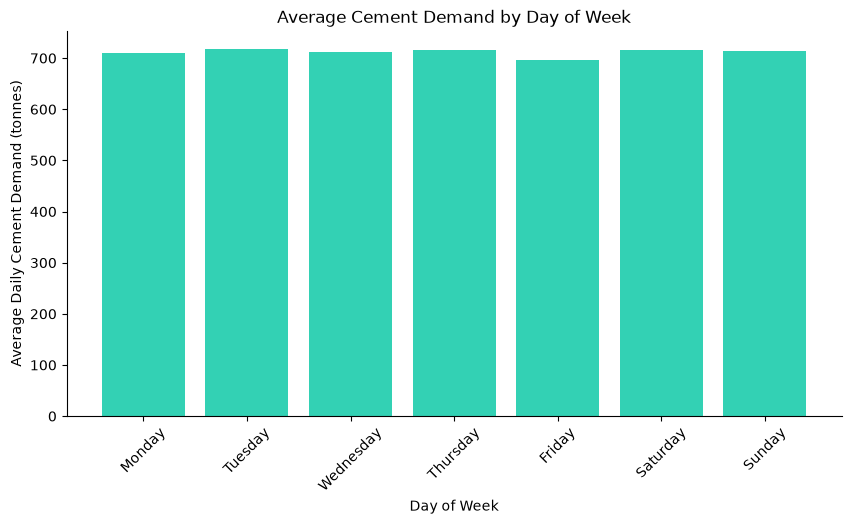

In [32]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_demand.index,
    weekday_demand.values,
    color ="#33D1B4"
)

plt.xlabel("Day of Week")
plt.ylabel("Average Daily Cement Demand (tonnes)")
plt.title("Average Cement Demand by Day of Week")

plt.xticks(rotation=45)

sns.despine()
plt.show()

- Average demand on weekly basis is relatively almost the same across days of the week with no special spike or fall out. This could be due that fact that we are looking at the average consumption across time

- Even at that we can still spell out that demand is relatively higher on Tuesday, Wednesday, Thursday Saturday and Sunday and remotely not higher on Friday and Monday.

- Looking at the average does not really tell the story that much. This is because different Site might have same or slightly different average consumption but still differe by demand site. So to capture this effect. Let's look at Demand Volatality measured by (mean, std and coffiecient of variation)

#### Demand Volatility

We are trying to answer how predictable or unstable is cement demand across MIG's construction sites?

In [33]:
site_volatility = (
    data.groupby("site_id")["consumed_tonnes"]
        .agg(
            average_demand="mean",
            demand_std="std"
        )
)

site_volatility["coefficient_of_variation"] = (
    site_volatility["demand_std"]
    / site_volatility["average_demand"]
)

site_volatility = site_volatility.sort_values(
    "coefficient_of_variation",
    ascending=False
)

site_volatility.round(2)

,average_demand,demand_std,coefficient_of_variation
site_id,,,
SITE_028,26.41,21.62,0.82
SITE_026,27.26,22.24,0.82
SITE_014,26.77,21.81,0.81
SITE_024,27.30,22.10,0.81
SITE_006,26.10,21.09,0.81
SITE_016,26.77,21.63,0.81
SITE_013,27.17,21.70,0.80
SITE_003,29.67,15.11,0.51
SITE_030,29.62,14.92,0.50


In [34]:
# Top 10 Site with the highest volatility in demand
site_volatility.head(10).round(2)

,average_demand,demand_std,coefficient_of_variation
site_id,,,
SITE_028,26.41,21.62,0.82
SITE_026,27.26,22.24,0.82
SITE_014,26.77,21.81,0.81
SITE_024,27.30,22.10,0.81
SITE_006,26.10,21.09,0.81
SITE_016,26.77,21.63,0.81
SITE_013,27.17,21.70,0.80
SITE_003,29.67,15.11,0.51
SITE_030,29.62,14.92,0.50


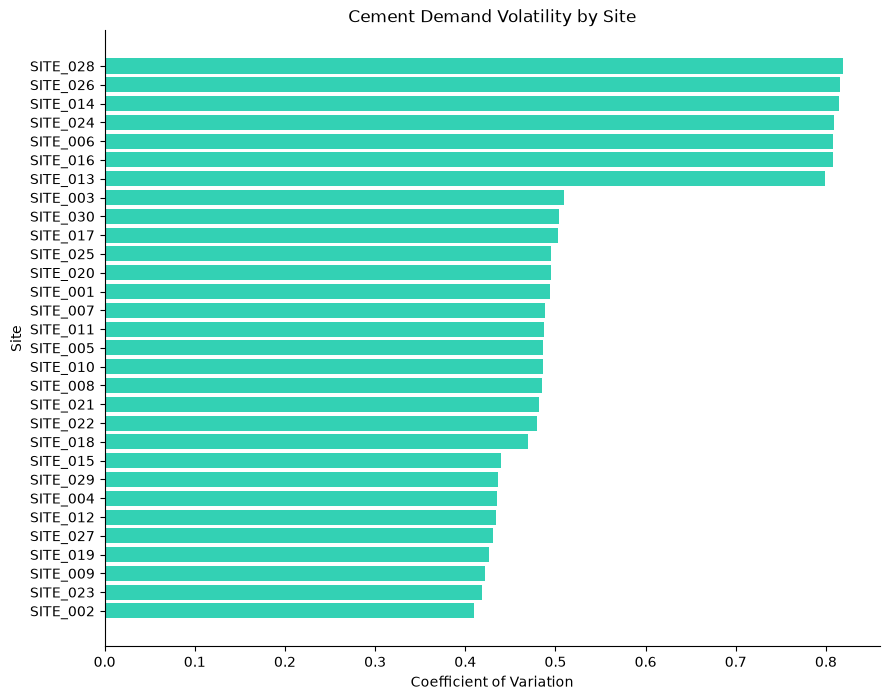

In [35]:
volatility_sorted = site_volatility.sort_values(
    "coefficient_of_variation"
)

plt.figure(figsize=(10, 8))

plt.barh(
    volatility_sorted.index,
    volatility_sorted["coefficient_of_variation"],
    color ="#33D1B4"
)

plt.xlabel("Coefficient of Variation")
plt.ylabel("Site")
plt.title("Cement Demand Volatility by Site")

sns.despine()
plt.show()

- One can say that Sites 28, 26, 14, 24 and 06 shows very volatal(that is variation in demand) while other Site depcits quiet predictable demand (less volatality)


#### Planned Pours vs Actual Consumption Analysis

- Planned cement requirements are compared with actual cement consumption to assess how closely site execution follows scheduled construction activity.

- This relationship is important because planned pour quantities may become a major explanatory variable in the forecasting model.

In [36]:
data["planning_difference"] = (
    data["consumed_tonnes"]
    - data["planned_pour_tonnes"]
)

In [37]:
data["planning_difference"].describe()

count    32880.000000
mean        -6.976684
std         12.280012
min        -69.620000
25%         -9.490000
50%          0.000000
75%          0.000000
max          0.000000
Name: planning_difference, dtype: float64

In [38]:
planning_correlation = (
    data["planned_pour_tonnes"]
    .corr(data["consumed_tonnes"])
)

print("Correlation:", round(planning_correlation, 3))

Correlation: 0.781


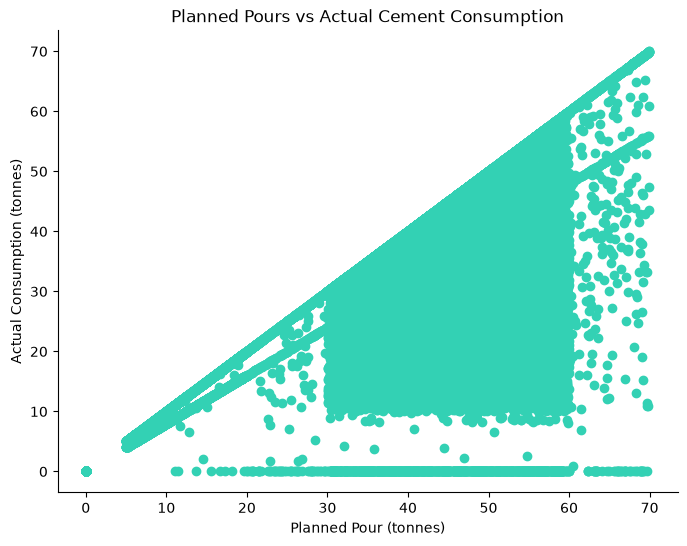

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(
    data["planned_pour_tonnes"],
    data["consumed_tonnes"],
    color ="#33D1B4"
)

plt.xlabel("Planned Pour (tonnes)")
plt.ylabel("Actual Consumption (tonnes)")
plt.title("Planned Pours vs Actual Cement Consumption")

sns.despine()
plt.show()

- This is there is a clear postive relationship between Planned Pour(tonned) vs Actual consumption. With a Correlation of 0.781. Although this does not in any way depicts casuation


In [40]:
site_planning = (
    data.groupby("site_id")
        .agg(
            average_planned=("planned_pour_tonnes", "mean"),
            average_actual=("consumed_tonnes", "mean"),
            average_difference=("planning_difference", "mean")
        )
)

site_planning["absolute_difference"] = (
    site_planning["average_difference"].abs()
)

site_planning = site_planning.sort_values(
    "absolute_difference",
    ascending=False
)

site_planning.head(10).round(2)

,average_planned,average_actual,average_difference,absolute_difference
site_id,,,,
SITE_011,43.29,29.73,-13.56,13.56
SITE_007,43.02,29.75,-13.26,13.26
SITE_008,43.01,29.83,-13.19,13.19
SITE_022,43.20,30.05,-13.16,13.16
SITE_021,43.22,30.12,-13.10,13.10
SITE_017,42.59,29.68,-12.91,12.91
SITE_020,42.52,29.73,-12.79,12.79
SITE_030,42.32,29.62,-12.70,12.70
SITE_001,42.58,30.16,-12.42,12.42


- Top 10 Sites with the highest difference between Planned Pour and Actual Pour

#### Looking at External factors(rainfal and temp) and demand

- Weather conditions may influence construction activity and therefore affect cement consumption.


In [41]:
weather_correlation = data[
    ["rain_mm", "avg_temp_c", "consumed_tonnes"]
].corr()

weather_correlation.round(3)

,rain_mm,avg_temp_c,consumed_tonnes
rain_mm,1.000,0.011,-0.180
avg_temp_c,0.011,1.000,0.035
consumed_tonnes,-0.180,0.035,1.000


- Rainfall shows very strong negative relationship with consumed tonned, which means more rainfall less consumed tonned. This actual makes sense. While temperature does show weak or little influence on consumed tonnes.

- This is does not in any way shows that temperature is less useful in affecting consumed tonnes. It just shows there is less linear relationship between them (temperature and consumed tonnes)


- This is there is a clear postive relationship between Planned Pour(tonned) vs Actual consumption. With a Correlation of 0.781. Although this does not in any way depicts casuation

- One can say that Sites 28, 26, 14, 24 and 06 shows very volatal(that is variation in demand) while other Site depcits quiet predictable demand (less volatality)



In [42]:
# look at the correlation between difference in planned and actual consumption and weather variables
weather_planning_correlation = data[
    ["rain_mm", "avg_temp_c", "planning_difference"]
].corr()

weather_planning_correlation.round(3)

,rain_mm,avg_temp_c,planning_difference
rain_mm,1.000,0.011,-0.249
avg_temp_c,0.011,1.000,0.043
planning_difference,-0.249,0.043,1.000


- This just justified the finding above, that rainfall influences cement consumption largely

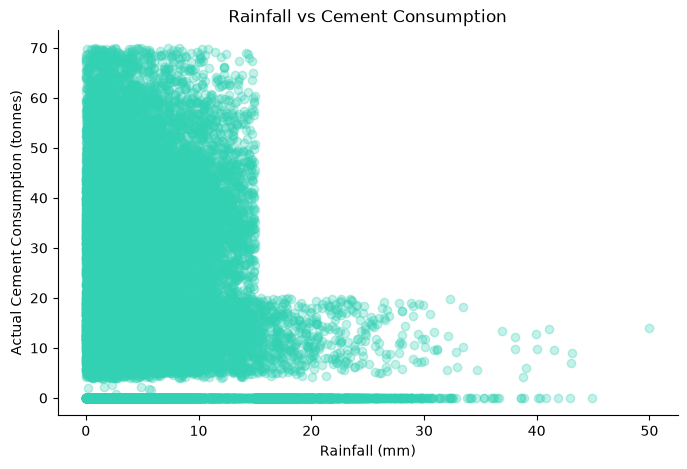

In [43]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data["rain_mm"],
    data["consumed_tonnes"],
    alpha=0.3,
    color ="#33D1B4"
)

plt.xlabel("Rainfall (mm)")
plt.ylabel("Actual Cement Consumption (tonnes)")
plt.title("Rainfall vs Cement Consumption")

sns.despine()
plt.show()

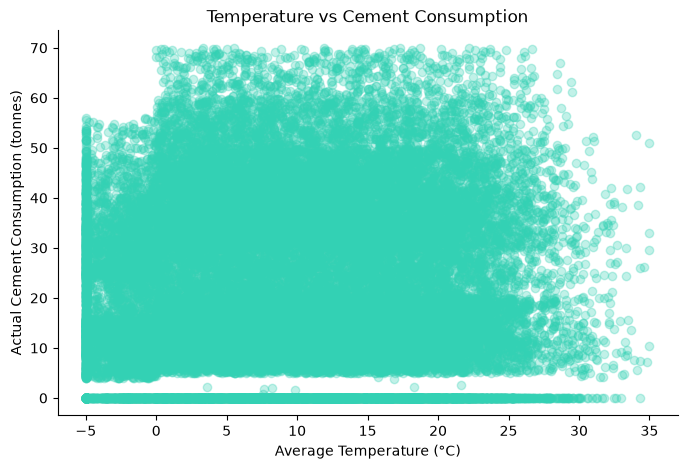

In [44]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data["avg_temp_c"],
    data["consumed_tonnes"],
    alpha=0.3,
    color ="#33D1B4"
)

plt.xlabel("Average Temperature (°C)")
plt.ylabel("Actual Cement Consumption (tonnes)")
plt.title("Temperature vs Cement Consumption")

sns.despine()
plt.show()

In [45]:
weather_planning_correlation = data[
    ["rain_mm", "avg_temp_c", "planning_difference"]
].corr()

weather_planning_correlation.round(3)

,rain_mm,avg_temp_c,planning_difference
rain_mm,1.000,0.011,-0.249
avg_temp_c,0.011,1.000,0.043
planning_difference,-0.249,0.043,1.000


In [46]:
# Dry days vs rainy days analysis
data["rain_status"] = data["rain_mm"].apply(
    lambda x: "Dry" if x == 0 else "Rain"
)

rain_summary = (
    data.groupby("rain_status")
        .agg(
            average_consumption=("consumed_tonnes", "mean"),
            average_planning_difference=("planning_difference", "mean"),
            observations=("consumed_tonnes", "count")
        )
)

rain_summary.round(2)

,average_consumption,average_planning_difference,observations
rain_status,,,
Dry,20.95,-5.14,26
Rain,23.72,-6.98,32854


- This also tells us alot, with only 26 obervation we have over 20.95 average consumed tonnes vs 32,854  observations with 23.72 average cement consumption in Dry and rainy season.

#### A look at the logistics behavior

Inventory behaviour is examined to understand how cement stock moves through MIG's construction sites.

The logistics features are:

- opening inventory,
- cement deliveries,
- cement consumption,
- closing inventory.

In [47]:
site_inventory = (
    data.groupby("site_id")
        .agg(
            average_opening_inventory=("opening_inventory_tonnes", "mean"),
            average_deliveries=("deliveries_tonnes", "mean"),
            average_consumption=("consumed_tonnes", "mean"),
            average_closing_inventory=("closing_inventory_tonnes", "mean")
        )
)

site_inventory["average_net_inventory_flow"] = (
    site_inventory["average_deliveries"]
    - site_inventory["average_consumption"]
)

site_inventory.round(2).head()

,average_opening_inventory,average_deliveries,average_consumption,average_closing_inventory,average_net_inventory_flow
site_id,,,,,
SITE_001,14.18,30.12,30.16,14.14,-0.04
SITE_002,9854.98,29.96,11.77,9873.16,18.19
SITE_003,17.13,29.64,29.67,17.09,-0.03
SITE_004,10236.61,30.20,11.51,10255.30,18.69
SITE_005,12.33,30.01,30.05,12.29,-0.04


In [48]:
site_inventory.sort_values(
    "average_closing_inventory",
    ascending=False
).head(10).round(2).head()

,average_opening_inventory,average_deliveries,average_consumption,average_closing_inventory,average_net_inventory_flow
site_id,,,,,
SITE_029,10368.47,30.14,11.51,10387.10,18.63
SITE_019,10286.76,30.32,11.50,10305.58,18.82
SITE_015,10263.44,29.98,11.16,10282.27,18.82
SITE_004,10236.61,30.20,11.51,10255.30,18.69
SITE_012,10152.30,29.95,11.33,10170.92,18.62


- Whenever average net inventory flow is > 0, this lead to inventory accumulation. It means there is pressure on inventory to increase

- Otherway round depicts inventory depletion

In [49]:
zero_inventory_by_site = (
    data.assign(
        zero_closing_inventory=
        data["closing_inventory_tonnes"] == 0
    )
    .groupby("site_id")["zero_closing_inventory"]
    .agg(
        zero_inventory_days="sum",
        total_records="count"
    )
)

zero_inventory_by_site["zero_inventory_pct"] = (
    zero_inventory_by_site["zero_inventory_days"]
    / zero_inventory_by_site["total_records"]
    * 100
)

zero_inventory_by_site.sort_values(
    "zero_inventory_pct",
    ascending=False
).round(2).head()

,zero_inventory_days,total_records,zero_inventory_pct
site_id,,,
SITE_022,563,1096,51.37
SITE_008,547,1096,49.91
SITE_011,546,1096,49.82
SITE_021,535,1096,48.81
SITE_020,531,1096,48.45


- A sharp look at Sites and number of times they ran into no inventory

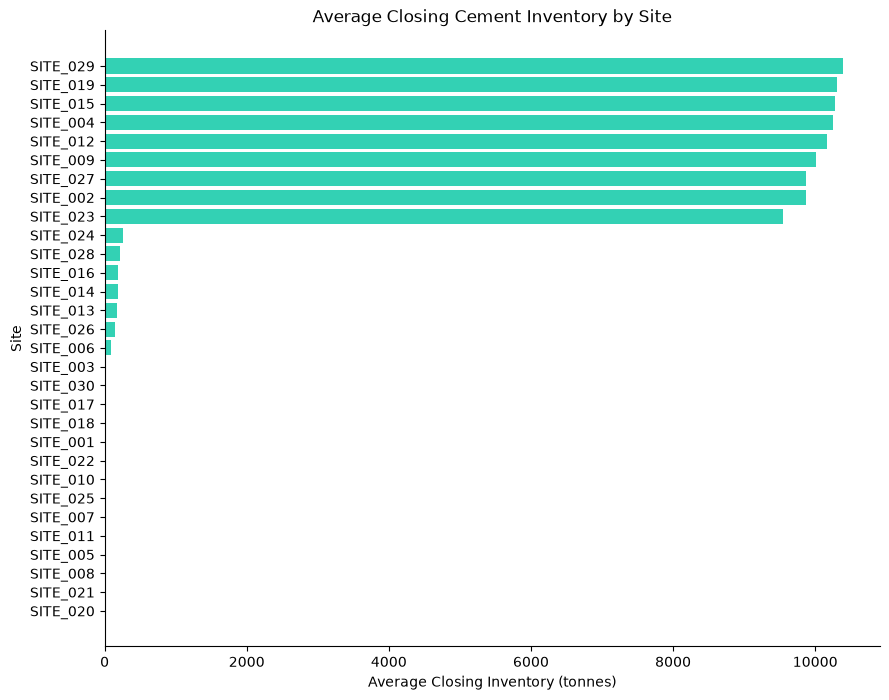

In [50]:
closing_inventory_sorted = site_inventory.sort_values(
    "average_closing_inventory"
)

plt.figure(figsize=(10, 8))

plt.barh(
    closing_inventory_sorted.index,
    closing_inventory_sorted["average_closing_inventory"],
    color ="#33D1B4"
)

plt.xlabel("Average Closing Inventory (tonnes)")
plt.ylabel("Site")
plt.title("Average Closing Cement Inventory by Site")

sns.despine()
plt.show()

In [51]:
region_summary = (
    data.groupby("region")
        .agg(
            number_of_sites=("site_id", "nunique"),
            total_consumption=("consumed_tonnes", "sum"),
            average_consumption=("consumed_tonnes", "mean")
        )
        .sort_values("total_consumption", ascending=False)
)

region_summary.round(2)

,number_of_sites,total_consumption,average_consumption
region,,,
East,12,318968.12,24.25
South,11,294887.83,24.46
West,4,108221.08,24.69
North,3,57852.18,17.59


In [52]:
behavior_summary = (
    data.groupby("behavior")
        .agg(
            number_of_sites=("site_id", "nunique"),
            average_consumption=("consumed_tonnes", "mean"),
            average_deliveries=("deliveries_tonnes", "mean"),
            average_closing_inventory=("closing_inventory_tonnes", "mean")
        )
)

behavior_summary.round(2)

,number_of_sites,average_consumption,average_deliveries,average_closing_inventory
behavior,,,,
aggressive,14,30.01,29.98,13.51
chaotic,7,26.82,27.07,180.05
conservative,9,11.52,29.96,10079.79


In [53]:
daily_demand_df["month_name"] = (
    daily_demand_df["date"].dt.month_name().str[:3]
)

In [54]:
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

In [55]:
month_day_heatmap = (
    daily_demand_df.pivot_table(
        index="day_of_week",
        columns="month_name",
        values="consumed_tonnes",
        aggfunc="mean"
    )
    .reindex(index=day_order, columns=month_order)
)

month_day_heatmap.round(2)

month_name,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
day_of_week,,,,,,,,,,,,
Monday,749.98,671.29,682.20,685.43,707.27,726.61,713.62,774.93,689.80,698.19,699.20,717.15
Tuesday,760.82,702.44,751.17,714.46,700.58,704.62,721.50,699.97,701.75,660.98,712.19,772.82
Wednesday,766.70,700.50,705.09,696.18,729.93,702.27,728.05,713.97,718.81,726.30,672.49,673.28
Thursday,739.34,710.91,709.16,748.92,707.63,674.57,771.86,680.20,696.14,715.46,720.54,739.57
Friday,703.54,714.00,726.51,715.17,664.70,688.73,722.34,653.32,677.70,674.50,698.00,720.49
Saturday,735.64,736.76,735.32,718.87,724.70,690.72,715.74,719.07,693.43,689.55,709.47,724.75
Sunday,684.65,689.74,751.78,757.93,710.36,744.46,695.70,674.17,662.36,695.49,765.04,728.00


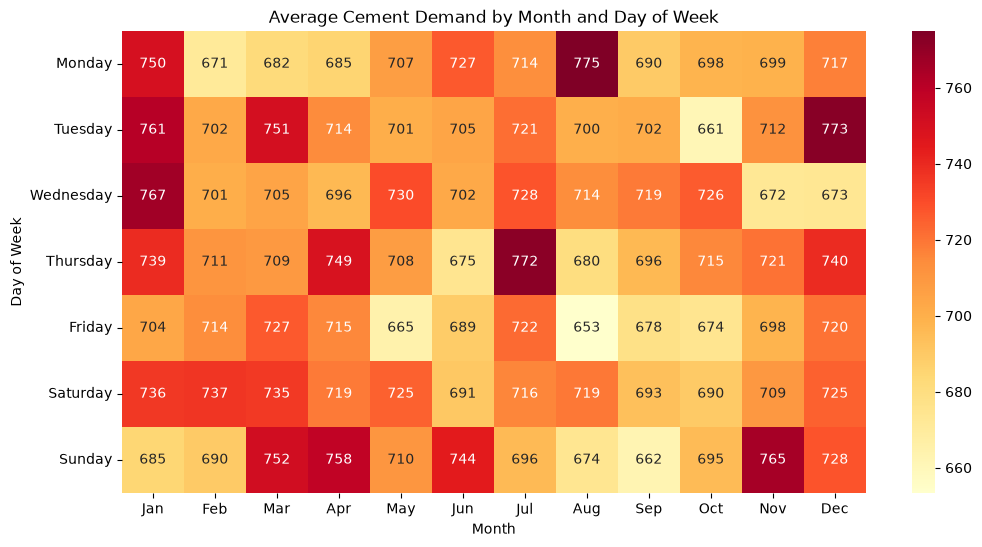

In [56]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    month_day_heatmap,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

plt.xlabel("Month")
plt.ylabel("Day of Week")
plt.title("Average Cement Demand by Month and Day of Week")

plt.show()

- We can see at glance the day of week and june with that MIG usually have high demand.

- High demand durings  Mondays around Auguest period, Tuesday demand typically spike during Dec, Wednesdays around Jan, Thurdays around Jul,  and Sunday around Nove. While Friday and Saturday show no clear patterns of very high demand.

- This help MIG know the combinations of month and weekday cement demand highest or lowest

- Rainfall shows very strong negative relationship with consumed tonned, which means more rainfall less consumed tonned. This actual makes sense. While temperature does show weak or little influence on consumed tonnes.

- This is does not in any way shows that temperature is less useful in affecting consumed tonnes. It just shows there is less linear relationship between them (temperature and consumed tonnes)

### EDA summary & Business findings

#### **Demand Distribution and Cement Type**

* Cement consumption is **right-skewed**, with some observations recording zero consumption while others exceed 69 tonnes. Average consumption is approximately **23.7 tonnes per operational record**.
* Demand differs across sites, with some sites clearly accounting for higher daily cement consumption than others. These differences may reflect variations in project size, activity level, pour schedules, or other site-specific factors.
* Cement demand is relatively similar across the three cement types, although **CEM II accounts for slightly more than 34% of total cement consumption**, making it the largest contributor.

#### **Demand Over Time and Seasonality**

* Cement consumption shows clear fluctuations over time, indicating that demand is not constant. The monthly trend helps reveal broader changes beyond daily fluctuations.
* Average monthly cement demand does not vary dramatically across months, suggesting that broad month-level seasonality may be relatively weak. More granular weekly and day-of-week patterns provide additional insight.
* Average demand across days of the week is also relatively similar, with no single weekday consistently dominating overall. However, demand appears somewhat higher on **Tuesday, Wednesday, Thursday, Saturday, and Sunday**, while **Monday and Friday** are comparatively lower.
* The month–weekday heatmap reveals more specific seasonal patterns that are hidden by simple averages. For example:

  * Mondays show relatively high demand around **August**.
  * Tuesdays tend to spike around **December**.
  * Wednesdays show stronger demand around **January**.
  * Thursdays show higher demand around **July**.
  * Sundays show relatively high demand around **November**.
  * Fridays and Saturdays do not show a similarly clear recurring high-demand pattern.
* These calendar patterns help MIG identify **specific month–weekday combinations associated with relatively high or low cement demand**, which may later improve short- and medium-term forecasting.

#### **Demand Volatility Across Sites**

* Demand volatility varies meaningfully across sites.
* **Sites 28, 26, 14, 24, and 06** appear among the more volatile sites, showing greater variation in cement demand relative to their typical consumption levels.
* Other sites exhibit more stable demand patterns and may therefore be easier to forecast.
* This suggests that forecasting difficulty is unlikely to be uniform across MIG's site portfolio.

#### **Planned Pours vs Actual Consumption**

* There is a clear positive relationship between **planned pour quantities and actual cement consumption**.
* The correlation is approximately **0.781**, indicating that higher planned pours are generally associated with higher actual cement consumption.
* This makes planned pour information a potentially valuable forecasting input.
* However, the relationship should not be interpreted as causal. A strong correlation shows association, not proof that planned pours directly cause actual consumption.

#### **Weather and Cement Demand**

* Rainfall shows a **strong negative relationship with cement consumption** in the historical data. In general, higher rainfall is associated with lower cement consumption, which is operationally plausible given the potential disruption of construction activity during wet conditions.
* Temperature, by contrast, shows only a weak linear relationship with cement consumption.
* This does **not** mean temperature is necessarily irrelevant. It only means that there is limited evidence of a strong **linear relationship** between temperature and consumption in the current analysis. Temperature could still interact with season, rainfall, site conditions, or other variables in more complex ways.

#### **Overall Business Interpretation**

The EDA shows that MIG's cement demand is influenced by several dimensions rather than by a single overall pattern. Demand varies across sites, displays meaningful volatility, responds strongly to planned construction activity, and appears sensitive to rainfall. Broad monthly and weekday averages are relatively stable, but more detailed calendar heatmaps reveal specific month–weekday combinations where demand becomes noticeably higher.

These findings support the need for a forecasting approach that preserves **site-level differences, cement type, calendar effects, planned pours, historical demand patterns, and weather information where justified by the data**.
